In [6]:
import numpy as np
import pandas as pd

X = np.load("/kaggle/input/fft-datasets/X_train_fft.npy")
y = np.load("/kaggle/input/fft-datasets/y_train_fft.npy")

print("Feature shape:", X.shape)
print("Target shape :", y.shape)

Feature shape: (17631, 693)
Target shape : (17631,)


In [8]:
WINDOW = 30

def make_windows_with_fft(df, window):
    X, y = [], []

    for eid in df.engine_id.unique():
        d = df[df.engine_id == eid].sort_values('cycle')
        data = d[sensor_cols].values
        rul = d['RUL'].values

        for i in range(len(data) - window):
            win = data[i:i+window]
            fft_feats = []

            for s in range(win.shape[1]):
                f1, f2, f3 = fft_features(win[:, s])
                fft_feats.extend([f1, f2, f3])

            combined = np.concatenate([win.flatten(), fft_feats])
            X.append(combined)
            y.append(rul[i + window])

    return np.array(X), np.array(y)

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input

model = Sequential([
    Input(shape=(X_train.shape[1],)),
    Dense(256, activation='relu'),
    Dropout(0.3),
    Dense(128, activation='relu'),
    Dense(1)
])

model.compile(optimizer='adam', loss='mse')
model.summary()

2025-12-28 13:20:36.962775: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1766928037.489437      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1766928037.634627      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1766928038.966537      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766928038.966579      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1766928038.966582      55 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 256)            │       177,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 210,689 (823.00 KB)

 Trainable params: 210,689 (823.00 KB)

 Non-trainable params: 0 (0.00 B)

In [11]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50,
    batch_size=256,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/50


I0000 00:00:1766928107.239939     162 service.cc:152] XLA service 0x7c59340099a0 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1766928107.239972     162 service.cc:160]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1766928107.239975     162 service.cc:160]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1766928107.583747     162 cuda_dnn.cc:529] Loaded cuDNN version 91002


46/56 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 4885.0479

I0000 00:00:1766928109.115796     162 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


56/56 ━━━━━━━━━━━━━━━━━━━━ 4s 30ms/step - loss: 4357.8086 - val_loss: 580.5505
Epoch 2/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 765.1822 - val_loss: 491.9855
Epoch 3/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 616.9605 - val_loss: 464.4926
Epoch 4/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 563.0305 - val_loss: 453.2425
Epoch 5/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 525.7087 - val_loss: 522.8987
Epoch 6/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 521.7872 - val_loss: 480.4059
Epoch 7/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 502.7880 - val_loss: 489.4484
Epoch 8/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 484.7780 - val_loss: 507.9952
Epoch 9/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 486.8175 - val_loss: 452.1777
Epoch 10/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 498.3776 - val_loss: 468.5552
Epoch 11/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 491.0019 - val_loss: 550.9626
Epoch 12/50
56/56 ━━━━━━━━━━━━━━━━━━━━ 

In [12]:
from sklearn.metrics import mean_squared_error

y_pred = model.predict(X_val).ravel()
rmse = np.sqrt(mean_squared_error(y_val, y_pred))
print("Validation RMSE with FFT features:", rmse)

111/111 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step
Validation RMSE with FFT features: 21.26447189310325


In [13]:
model.save("rul_lstm_model_fd001.h5")

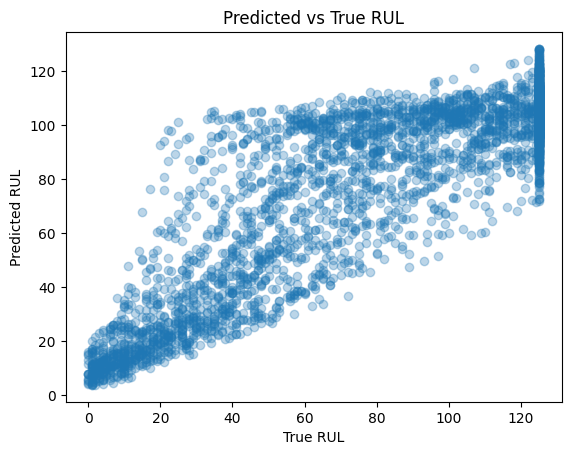

In [14]:
import matplotlib.pyplot as plt

plt.figure()
plt.scatter(y_val, y_pred, alpha=0.3)
plt.xlabel("True RUL")
plt.ylabel("Predicted RUL")
plt.title("Predicted vs True RUL")
plt.show()